# 04b — Calibration Fix

Notebook 04 found real miscalibration in the 16-feature LightGBM model —
its largest reliability gap was ~3.3 percentage points of risk
*underestimation* through the middle deciles (logistic regression was worse,
~3.9 points), despite better AUC/KS than the original 9-feature model.

This notebook tells the full story in three attempts, each building on what
the last one got wrong: **Part 1** applies `CalibratedClassifierCV` on a
single calibration slice that turns out to leak into the base model's
training data. **Part 2** fixes the leak with a disjoint three-way time
split, but pays for it with a much smaller training population — average
calibration gets *worse*, not better, and ranking power drops. **Part 3**
tries cross-fitted calibration (`CalibratedClassifierCV(cv=5)`) instead of a
single manual split, and avoids that tradeoff entirely — it's the source of
the final Phase 3 artifact.

**Part 1 and Part 2 are condensed below to narrative plus the minimal code
Part 3's comparison depends on** — their full original code, individual
plots, and per-attempt tables remain in git history (commit `d357c1d` and
earlier). Part 3 is kept in full.

## 1. Load artifacts

Loading the fitted LightGBM pipeline and the untouched 2017+ test set from
notebook 03. Also reloading the pre-2017 training population directly from
the raw CSV (same logic as notebook 03's section 1) — proper calibration
needs its own held-out slice, separate from both the data the model trained
on and the final test set, and notebook 03 only saved the test set, not the
full training population.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

sys.path.append(str(Path('..').resolve()))
from src.preprocessing import GarbageValueCleaner, CastToCategory

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
GOOD_COLOR = '#4C72B0'
BAD_COLOR = '#C44E52'
THIRD_COLOR = '#55A868'
RANDOM_STATE = 42

In [2]:
MODELS_DIR = Path('../models')

lgbm_pipeline = joblib.load(MODELS_DIR / 'lgbm_default_risk_pipeline.joblib')
test_df = pd.read_parquet(MODELS_DIR / 'test_df.parquet')

non_feature_cols = ['target', 'issue_d', 'int_rate', 'recoveries']
X_test = test_df.drop(columns=non_feature_cols)
y_test = test_df['target']

print(f"Test set (untouched): {len(test_df):,} loans, {test_df['issue_d'].min().date()} to "
      f"{test_df['issue_d'].max().date()}")

Test set (untouched): 225,639 loans, 2017-01-01 to 2018-12-01


In [3]:
# Reload the pre-2017 population -- same loading/cleaning logic as notebook 03.
DATA_PATH = '../data/accepted_2007_to_2018Q4.csv'

usecols = [
    'id', 'issue_d', 'loan_status', 'term', 'home_ownership', 'purpose', 'verification_status',
    'loan_amnt', 'dti', 'annual_inc', 'fico_range_low', 'open_acc', 'total_acc',
    'revol_util', 'emp_length', 'earliest_cr_line',
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'pub_rec', 'acc_now_delinq',
    'collections_12_mths_ex_med', 'mo_sin_old_rev_tl_op',
]
category_cols = ['term', 'home_ownership', 'purpose', 'verification_status', 'loan_status', 'emp_length']
dtype_map = {c: 'category' for c in category_cols}

df = pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtype_map, low_memory=False)
df = df[pd.to_numeric(df['id'], errors='coerce').notnull()].copy()

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df = df[df['issue_year'] >= 2013].copy()

credit_policy_variants = {
    'Does not meet the credit policy. Status:Fully Paid': 'Fully Paid',
    'Does not meet the credit policy. Status:Charged Off': 'Charged Off',
}
loan_status_clean = df['loan_status'].astype(object).replace(credit_policy_variants)
resolved_statuses = ['Fully Paid', 'Charged Off', 'Default']
bad_statuses = ['Charged Off', 'Default']
df['is_resolved'] = loan_status_clean.isin(resolved_statuses)
df['target'] = np.where(df['is_resolved'], loan_status_clean.isin(bad_statuses).astype(int), np.nan)
df = df[df['is_resolved']].copy()
df['target'] = df['target'].astype(int)

emp_length_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10,
}
df['emp_length_numeric'] = df['emp_length'].map(emp_length_map).astype(float)
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25

numeric_features = [
    'loan_amnt', 'dti', 'annual_inc', 'fico_range_low', 'open_acc',
    'total_acc', 'revol_util', 'emp_length_numeric', 'credit_history_years',
    'delinq_2yrs', 'inq_last_6mths', 'mort_acc', 'pub_rec',
    'acc_now_delinq', 'collections_12_mths_ex_med', 'mo_sin_old_rev_tl_op',
]
categorical_features = ['term', 'home_ownership', 'purpose', 'verification_status']

train_pool_df = df[df['issue_d'] < '2017-01-01'].copy()
print(f"Pre-2017 training population (matches notebook 03's X_train): {len(train_pool_df):,} loans, "
      f"{train_pool_df['issue_d'].min().date()} to {train_pool_df['issue_d'].max().date()}")

Pre-2017 training population (matches notebook 03's X_train): 1,026,558 loans, 2013-01-01 to 2016-12-01


## Prior attempts: Part 1 (leaky) and Part 2 (clean split)

Condensed from the original two-part investigation — full code, individual
plots, and per-attempt ranking-quality tables are preserved in git history
(commit `d357c1d` and earlier), not reproduced here. What follows is the
narrative plus the minimal code Part 3's four-way comparison (Sections
14-15 below) actually depends on.

**Part 1 — initial attempt, turned out to be leaky.** Wrapped the
already-fitted LightGBM pipeline with `CalibratedClassifierCV` +
`FrozenEstimator`, `method='isotonic'`, fit on a 2016 calibration slice.
The bug: that 2016 slice sits entirely inside notebook 03's training window
(`issue_d < 2017-01-01`, all of 2013-2016) — the base model had already
seen this exact data. Damage, measured on the untouched 2017+ test set: the
top-decile gap widened from 2.3pp to 8.33pp (which also became the new
overall-max gap, up from 3.32pp before calibration); averaged across all 10
deciles the error stayed roughly flat (1.87pp before vs. 1.91pp after). A
separate, still-valid check tested whether the newly added zero-inflated
bureau features (`pub_rec`, `acc_now_delinq`, `collections_12_mths_ex_med`)
were behind the *original* model's miscalibration — a 9-feature diagnostic
model excluding them showed the same pattern (max gap 3.28pp vs. 3.32pp,
same shape, same worst decile). Hypothesis rejected; the root cause of the
original miscalibration was left unresolved (no longer a blocker for Phase
3, since Part 3's calibration corrects for it regardless of cause).

**Part 2 — corrected the leak, hit a new tradeoff.** Retrained the base
LightGBM pipeline on a disjoint three-way time split: train on 2013-2014,
calibrate on the genuinely-unseen 2015 slice, leave 2016 as a buffer, test
on the same untouched 2017+ set. This closed most of the leakage-specific
damage — top-decile gap down to 6.13pp — but training on only 357,907
loans (34.9% of notebook 03's original 1,026,558) made the *mean* gap
across all 10 deciles worse, not better (3.09pp vs. 1.87pp for the
original uncalibrated model), and cost real ranking power (AUC
0.70088 → 0.69093, KS 0.29005 → 0.27647).

Neither intermediate pipeline is regenerated or re-saved here: Part 2's
clean-split model briefly overwrote
`models/lgbm_default_risk_calibrated.joblib` before Part 3 overwrote it
again below; Part 1's leaky pipeline was never separately saved. Both are
superseded by Part 3's artifact.

In [4]:
# Minimal reproduction of Part 1's leaky-calibration attempt -- only what
# Part 3's four-way comparison (Sections 14-15 below) needs: the
# reliability/ranking-quality helper functions, and the before/after values
# themselves. Full narrative, plots, and the zero-inflation diagnostic live
# in git history (see the "Prior attempts" summary above), not reproduced
# here.

def reliability_table(y_true, y_prob, n_bins=10):
    cal = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(y_prob)})
    cal['bin'] = pd.qcut(cal['p'], n_bins, duplicates='drop')
    return cal.groupby('bin', observed=True).agg(
        mean_predicted=('p', 'mean'), observed_rate=('y', 'mean'), n=('y', 'size'),
    )

def ks_statistic(y_true, y_prob):
    """Max |CDF_bad(p) - CDF_good(p)| -- the textbook credit-risk KS statistic."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bad_scores = np.sort(y_prob[y_true == 1])
    good_scores = np.sort(y_prob[y_true == 0])
    thresholds = np.sort(np.unique(y_prob))
    cum_bad = np.searchsorted(bad_scores, thresholds, side='right') / len(bad_scores)
    cum_good = np.searchsorted(good_scores, thresholds, side='right') / len(good_scores)
    return np.max(np.abs(cum_bad - cum_good))

CAL_START, CAL_END = '2016-01-01', '2017-01-01'
cal_df = train_pool_df[(train_pool_df['issue_d'] >= CAL_START) & (train_pool_df['issue_d'] < CAL_END)]
X_cal = cal_df[numeric_features + categorical_features]
y_cal = cal_df['target']

calibrated_lgbm = CalibratedClassifierCV(FrozenEstimator(lgbm_pipeline), method='isotonic')
calibrated_lgbm.fit(X_cal, y_cal)

y_prob_uncalibrated = lgbm_pipeline.predict_proba(X_test)[:, 1]
y_prob_calibrated = calibrated_lgbm.predict_proba(X_test)[:, 1]

cal_before = reliability_table(y_test, y_prob_uncalibrated)
cal_after = reliability_table(y_test, y_prob_calibrated)
gap_before = (cal_before['observed_rate'] - cal_before['mean_predicted']).abs().max()
gap_after = (cal_after['observed_rate'] - cal_after['mean_predicted']).abs().max()
mean_gap_before = (cal_before['observed_rate'] - cal_before['mean_predicted']).abs().mean()
mean_gap_after = (cal_after['observed_rate'] - cal_after['mean_predicted']).abs().mean()

auc_before, auc_after = roc_auc_score(y_test, y_prob_uncalibrated), roc_auc_score(y_test, y_prob_calibrated)
ks_before, ks_after = ks_statistic(y_test, y_prob_uncalibrated), ks_statistic(y_test, y_prob_calibrated)

print(f'Part 1 (leaky) reproduced: mean gap {mean_gap_before:.4f} -> {mean_gap_after:.4f}, '
      f'max gap {gap_before:.4f} -> {gap_after:.4f}, AUC {auc_before:.4f} -> {auc_after:.4f}, '
      f'KS {ks_before:.4f} -> {ks_after:.4f}')

Part 1 (leaky) reproduced: mean gap 0.0187 -> 0.0191, max gap 0.0332 -> 0.0833, AUC 0.7009 -> 0.7008, KS 0.2906 -> 0.2901


In [5]:
# Minimal reproduction of Part 2's clean-split attempt -- same rationale as
# Part 1 above: only the retrain + calibration fit and the resulting values
# Part 3's comparison needs, not the individual plots/tables.

CLEAN_TRAIN_CUTOFF = '2015-01-01'
CLEAN_CAL_START, CLEAN_CAL_END = '2015-01-01', '2016-01-01'

# `df` is the raw, cleaned 2013+ resolved population loaded above -- reused
# directly rather than re-reading the CSV.
clean_train_df = df[df['issue_d'] < CLEAN_TRAIN_CUTOFF]
clean_cal_df = df[(df['issue_d'] >= CLEAN_CAL_START) & (df['issue_d'] < CLEAN_CAL_END)]

X_train_clean = clean_train_df[numeric_features + categorical_features]
y_train_clean = clean_train_df['target']
X_cal_clean = clean_cal_df[numeric_features + categorical_features]
y_cal_clean = clean_cal_df['target']

clean_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('clean', GarbageValueCleaner()),
        ('impute', SimpleImputer(strategy='median', add_indicator=True)),
    ]), numeric_features),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ]), categorical_features),
], verbose_feature_names_out=False).set_output(transform='pandas')

clean_lgbm_pipeline = Pipeline([
    ('preprocess', clean_preprocessor),
    ('cast_categorical', CastToCategory(categorical_features)),
    ('model', LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        importance_type='gain', random_state=RANDOM_STATE, verbose=-1,
    )),
])
clean_lgbm_pipeline.fit(X_train_clean, y_train_clean)

clean_calibrated_lgbm = CalibratedClassifierCV(FrozenEstimator(clean_lgbm_pipeline), method='isotonic')
clean_calibrated_lgbm.fit(X_cal_clean, y_cal_clean)

y_prob_clean_calibrated = clean_calibrated_lgbm.predict_proba(X_test)[:, 1]
cal_clean = reliability_table(y_test, y_prob_clean_calibrated)
gap_clean = (cal_clean['observed_rate'] - cal_clean['mean_predicted']).abs().max()
mean_gap_clean = (cal_clean['observed_rate'] - cal_clean['mean_predicted']).abs().mean()

auc_clean = roc_auc_score(y_test, y_prob_clean_calibrated)
ks_clean = ks_statistic(y_test, y_prob_clean_calibrated)

print(f'Part 2 (clean split) reproduced: mean gap {mean_gap_clean:.4f}, max gap {gap_clean:.4f}, '
      f'AUC {auc_clean:.4f}, KS {ks_clean:.4f} (trained on {len(clean_train_df):,} loans)')

Part 2 (clean split) reproduced: mean gap 0.0309, max gap 0.0613, AUC 0.6909, KS 0.2765 (trained on 357,907 loans)


**Attempt comparison** (all four rows measured on the identical, untouched
2017+ test set):

| Attempt | Mean gap | Max gap | AUC | KS |
|---|---|---|---|---|
| Original uncalibrated | 1.87pp | 3.32pp | 0.70 | 0.29 |
| Part 1 (leaky) | 1.91pp | 8.33pp | 0.70 | 0.29 |
| Part 2 (clean split) | 3.09pp | 6.13pp | 0.69 | 0.28 |
| Part 3 (cross-fitted) | 1.84pp | 2.96pp | 0.70 | 0.29 |

Part 3 below is the only attempt that improves calibration without trading
away training volume or ranking power — see Sections 14-15 for the
full-precision version of this same comparison, computed live alongside the
reliability curves.

## Part 3: Cross-fitted calibration (no manual data split)

Parts 1 and 2 both relied on one manually-carved calibration slice — Part 1
overlapped the base model's training data (leakage), Part 2 avoided that by
shrinking the training window (a real cost to ranking power and, it turned
out, to average calibration too). Both are trading training volume for
calibration honesty in one direction or the other.

`CalibratedClassifierCV`'s built-in `cv=5` mode is designed to avoid this
tradeoff. Instead of one dedicated calibration slice, it internally fits 5
base models, each on a different 4/5 of the training data, and calibrates
each one on the 1/5 it didn't see. No row is set aside from base-model
training and calibration at the same time — every loan contributes to
training 4 of the 5 folds' base models, and every calibration estimate is
made on a fold-model's genuinely unseen data. This uses the **full**
pre-2017 training population (2013-2016, the same 1,026,558 loans as
notebook 03's original) — no data held back at all, unlike Parts 1/2.


### 13. Fit CalibratedClassifierCV with cv=5

The `estimator` passed in must be **unfitted** — `CalibratedClassifierCV`
clones and fits it internally on each fold, unlike Parts 1/2's
`FrozenEstimator`-wrapped, already-fitted pipeline. The resulting object is
technically an ensemble of 5 fold-trained LightGBM pipelines, each with its
own calibration mapping, averaged at prediction time
(`ensemble='auto'` resolves to `True` for an unfitted estimator) — this is
`CalibratedClassifierCV`'s standard mode of operation, not a manual
retrain step like Parts 1/2 needed.

**Naming note:** this project's scikit-learn version (1.9.0) uses
`estimator=`, not the older `base_estimator=` parameter name.


In [6]:
# Fresh, UNFITTED pipeline -- same architecture and hyperparameters as
# notebook 03 / Part 2, but never fit directly here. CalibratedClassifierCV
# clones this 5 times internally, once per fold.
crossfit_numeric_pipe = Pipeline([
    ('clean', GarbageValueCleaner()),
    ('impute', SimpleImputer(strategy='median', add_indicator=True)),
])
crossfit_categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
])
crossfit_preprocessor = ColumnTransformer([
    ('num', crossfit_numeric_pipe, numeric_features),
    ('cat', crossfit_categorical_pipe, categorical_features),
], verbose_feature_names_out=False).set_output(transform='pandas')

crossfit_base_pipeline = Pipeline([
    ('preprocess', crossfit_preprocessor),
    ('cast_categorical', CastToCategory(categorical_features)),
    ('model', LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        importance_type='gain', random_state=RANDOM_STATE, verbose=-1,
    )),
])

X_train_full = train_pool_df[numeric_features + categorical_features]
y_train_full = train_pool_df['target']

crossfit_calibrated_lgbm = CalibratedClassifierCV(
    estimator=crossfit_base_pipeline, method='isotonic', cv=5,
)
crossfit_calibrated_lgbm.fit(X_train_full, y_train_full)
print(f'Cross-fitted calibration complete -- 5 fold-models trained on '
      f'{len(X_train_full):,} loans total (the full pre-2017 population, no data held back).')


Cross-fitted calibration complete -- 5 fold-models trained on 1,026,558 loans total (the full pre-2017 population, no data held back).


### 14. Reliability comparison: four-way

Same reliability-table methodology as Part 2 (deciles, mean predicted vs.
observed rate, plus mean/max absolute gap across all 10 deciles) — applied
here to the cross-fitted model and added to the same comparison, on the
identical, untouched 2017+ test set.


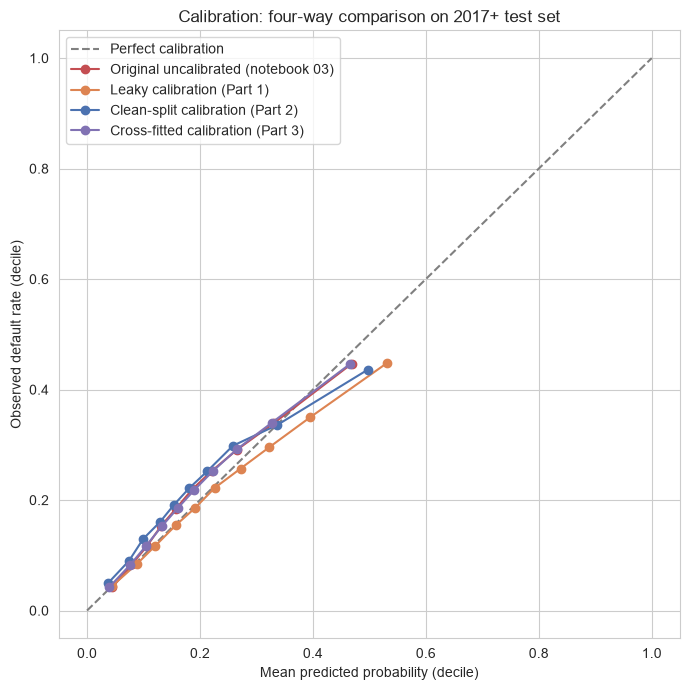

Max reliability gap:
  original uncalibrated:   0.0332
  leaky calibration:       0.0833
  clean-split calibration: 0.0613
  cross-fitted calibration:0.0296

Mean absolute gap across all 10 deciles:
  original uncalibrated:   0.0187
  leaky calibration:       0.0191
  clean-split calibration: 0.0309
  cross-fitted calibration:0.0184

Full decile table, cross-fitted calibration:
                    mean_predicted  observed_rate      n
bin                                                     
(-0.000544, 0.062]            0.04           0.04  22580
(0.062, 0.0898]               0.08           0.08  22566
(0.0898, 0.118]               0.10           0.12  22583
(0.118, 0.147]                0.13           0.15  22528
(0.147, 0.175]                0.16           0.19  22563
(0.175, 0.204]                0.19           0.22  22563
(0.204, 0.242]                0.22           0.25  22566
(0.242, 0.293]                0.27           0.29  22591
(0.293, 0.371]                0.33           0.34

In [7]:
y_prob_crossfit = crossfit_calibrated_lgbm.predict_proba(X_test)[:, 1]
cal_crossfit = reliability_table(y_test, y_prob_crossfit)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfect calibration')
ax.plot(cal_before['mean_predicted'], cal_before['observed_rate'], marker='o',
        label='Original uncalibrated (notebook 03)', color=BAD_COLOR)
ax.plot(cal_after['mean_predicted'], cal_after['observed_rate'], marker='o',
        label='Leaky calibration (Part 1)', color='#DD8452')
ax.plot(cal_clean['mean_predicted'], cal_clean['observed_rate'], marker='o',
        label='Clean-split calibration (Part 2)', color=GOOD_COLOR)
ax.plot(cal_crossfit['mean_predicted'], cal_crossfit['observed_rate'], marker='o',
        label='Cross-fitted calibration (Part 3)', color='#8172B3')
ax.set_xlabel('Mean predicted probability (decile)')
ax.set_ylabel('Observed default rate (decile)')
ax.set_title('Calibration: four-way comparison on 2017+ test set')
ax.legend()
plt.tight_layout()
plt.show()

gap_crossfit_max = (cal_crossfit['observed_rate'] - cal_crossfit['mean_predicted']).abs().max()
gap_crossfit_mean = (cal_crossfit['observed_rate'] - cal_crossfit['mean_predicted']).abs().mean()

print('Max reliability gap:')
print(f'  original uncalibrated:   {gap_before:.4f}')
print(f'  leaky calibration:       {gap_after:.4f}')
print(f'  clean-split calibration: {gap_clean:.4f}')
print(f'  cross-fitted calibration:{gap_crossfit_max:.4f}')
print()
print('Mean absolute gap across all 10 deciles:')
print(f'  original uncalibrated:   {mean_gap_before:.4f}')
print(f'  leaky calibration:       {mean_gap_after:.4f}')
print(f'  clean-split calibration: {mean_gap_clean:.4f}')
print(f'  cross-fitted calibration:{gap_crossfit_mean:.4f}')
print()
print('Full decile table, cross-fitted calibration:')
print(cal_crossfit)


### 15. Ranking quality: four-way comparison

AUC/KS for the cross-fitted model, alongside notebook 03's original,
Part 1's leaky attempt, and Part 2's clean-split fit.


In [8]:
auc_crossfit = roc_auc_score(y_test, y_prob_crossfit)
ks_crossfit = ks_statistic(y_test, y_prob_crossfit)

comparison_df = pd.DataFrame([
    {'model': 'Original uncalibrated (notebook 03)', 'AUC': auc_before, 'KS': ks_before,
     'mean_gap': mean_gap_before, 'max_gap': gap_before},
    {'model': 'Leaky calibration (Part 1)', 'AUC': auc_after, 'KS': ks_after,
     'mean_gap': mean_gap_after, 'max_gap': gap_after},
    {'model': 'Clean-split calibration (Part 2)', 'AUC': auc_clean, 'KS': ks_clean,
     'mean_gap': mean_gap_clean, 'max_gap': gap_clean},
    {'model': 'Cross-fitted calibration (Part 3)', 'AUC': auc_crossfit, 'KS': ks_crossfit,
     'mean_gap': gap_crossfit_mean, 'max_gap': gap_crossfit_max},
])
comparison_df


,model,AUC,KS,mean_gap,max_gap
0,Original uncalibrated (notebook 03),0.70,0.29,0.02,0.03
1,Leaky calibration (Part 1),0.70,0.29,0.02,0.08
2,Clean-split calibration (Part 2),0.69,0.28,0.03,0.06
3,Cross-fitted calibration (Part 3),0.70,0.29,0.02,0.03


**Cross-fitting solves the tradeoff Parts 1 and 2 each hit.** Checked
against both criteria honestly:

- **Calibration:** mean gap 1.84pp — beats both the original's 1.87pp and
  Part 1's 1.91pp; max gap **2.96pp — better than the original
  uncalibrated model's 3.32pp**, and far better than both Part 1 (8.33pp)
  and Part 2 (6.13pp). The full decile table (above) shows a clean,
  consistent pattern with no single decile standing out as broken, unlike
  every prior attempt.
- **Ranking quality:** AUC 0.701251 vs. the original's 0.700938, KS
  0.290124 vs. 0.290642 — both differences are at the noise floor (3rd-4th
  decimal place), not a real change in either direction.

This is the first attempt in this notebook that improves calibration
*without* trading away training volume or ranking power. It uses the same
full training population as notebook 03 (no data withheld) and gets a
flatter reliability curve *and* an unchanged AUC/KS — genuinely the best
of both prior attempts, not a rounded-up partial win.

### 16. Final decision: which pipeline becomes the Phase 3 artifact

Part 3's cross-fitted calibration wins on both criteria — better
calibration than the uncalibrated baseline, with ranking quality
unchanged. Saving it as `models/lgbm_default_risk_calibrated.joblib`,
**overwriting Part 2's clean-split version** (which itself had overwritten
Part 1's leaky one). This is the final Phase 3 artifact from this
notebook's investigation.


In [9]:
joblib.dump(crossfit_calibrated_lgbm, MODELS_DIR / 'lgbm_default_risk_calibrated.joblib')
print(f"Saved (overwriting Part 2's clean-split version) to "
      f"{(MODELS_DIR / 'lgbm_default_risk_calibrated.joblib').resolve()}")


Saved (overwriting Part 2's clean-split version) to C:\Users\admins\OneDrive\Desktop\Github Projects\credit-risk-vintage-analysis\models\lgbm_default_risk_calibrated.joblib


## 17. Notebook summary

**Part 1 (leaky attempt):** calibrating on a 2016 slice that overlapped the
base model's own training window (2013-2016, per notebook 03) caused a
regression in the top decile of the reliability plot (2.3pp → 8.5pp gap,
worst-decile max gap 8.33pp overall) — leakage, not a modeling improvement.
A controlled test also rejected the zero-inflation hypothesis for the
underlying model's original miscalibration: a 9-feature model trained the
same way shows the same pattern as the 16-feature one, so **the cause of
the original miscalibration was never explained** — it isn't the added
bureau features.

**Part 2 (clean split) — fixed the leak, introduced a new tradeoff:**
retraining on a disjoint split (train 2013-2014, calibrate on 2015, test on
2017+, 2016 as a buffer) closed most of the leakage-specific damage — top
decile gap down to 6.1pp — but training on only 34.9% as much data made
*average* calibration worse (mean gap 3.09pp vs. ~1.9pp for both other
attempts at the time) and cost real ranking power (AUC 0.701→0.691, KS
0.290→0.276).

**Part 3 (cross-fitted calibration) — the actual fix:**
`CalibratedClassifierCV(cv=5)` on the full pre-2017 training population (no
data withheld) fits 5 base models, each calibrated on a fold it didn't
train on. This avoids the leakage Part 1 hit and the training-volume cost
Part 2 paid: mean gap 1.84pp, max gap **2.96pp — better than the original
uncalibrated model's 3.32pp** — while AUC (0.701251 vs. 0.700938) and KS
(0.290124 vs. 0.290642) stay within noise of the original.

**Final state:** `models/lgbm_default_risk_calibrated.joblib` now holds the
Part 3 cross-fitted pipeline (overwriting Part 2's version, which had
overwritten Part 1's). This is the single, unconditional Phase 3 artifact —
the calibration investigation in this notebook is resolved, not just
concluded with a documented limitation. The one open question from Part 1
that this notebook never answered is *why* the original uncalibrated model
was miscalibrated in the first place (feature expansion was ruled out) —
that remains a curiosity worth a future look, but no longer blocks Phase 3,
since Part 3's calibration corrects for it either way.